# José Roberto 18-02-2026
-------------------------

Proposta: Realizar análise dos dados da pesquisa de avaliação institucional,realizada em 2025, no IFG - Campus Goiânia, contemplando respostas de:
- **Discentes**
- **Docentes**  
- **Técnicos-Administrativos**
---
# Funcionalidades
### Análise de Respostas da Pesquisa
- Estatísticas descritivas por perfil (Discentes, Docentes, TAEs)
- Tabelas resumo por Eixo-Dimensão
- Visualizações gráficas detalhadas
- Infográfico executivo

### Análise Demográfica
- Incorporação de dados de matrículas e servidores
- Cálculo de taxas de resposta
- Análise de representatividade amostral
- Estatísticas por curso, modalidade e turno

### Arquivos Necessários
1. **Arquivo de Respostas** (obrigatório):
   - 3 abas: DISCENTES, DOCENTES, TAES
   - Respostas em escala Likert

2. **Arquivo Demográfico** (recomendado):
   - Aba DISCENTES: cursos e matrículas
   - Aba SERVIDORES: total de docentes e TAEs

---

1. Instalação das bibliotecas:

In [13]:
# Instalar dependências
import sys
import subprocess

# Verificar se está no Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f" Ambiente detectado: {'Google Colab' if IN_COLAB else 'Execução Local'}")

# Instalar pacotes# bibliotecas necessárias
#!pip install pandas numpy matplotlib seaborn openpyxl -q
%pip install pandas numpy matplotlib seaborn openpyxl -q
print("..... Instalacao concluida!")

 Ambiente detectado: Execução Local
Note: you may need to restart the kernel to use updated packages.
..... Instalacao concluida!



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Upload dos Arquivos Excel

Faça upload dos arquivos necessários (arquvos locais se fora do Colab ou carregados via upload interativo):

In [14]:
import os

if IN_COLAB:
    from google.colab import files

    # print(" *****************************************************************************************")
    # print(" **** ATENÇÃO >>> Faça o upload do arquivo script (python) de análise dados dos dados ****")
    # print(" *****************************************************************************************")
    # print("   o nome padrão do arquivo é: analise_pesquisa_2025.py\n")

    
    # uploaded = files.upload()  
    # arquivo_py = list(uploaded_pesquisa.keys())[0]
    # # aceita somente arquivos .py
    # if not arquivo_py.endswith(\".py\"):
    #     raise ValueError(f\"Erro: arquivo \'{arquivo_py}\' nao e um script python!\")\n,
    # print(f" Arquivo carregado: {arquivo_pesquisa}")
    # print(f"    Tamanho: {os.path.getsize(arquivo_pesquisa) / 1024:.2f} KB")

    # print("\n" + "="*70)
    
    print(" ARQUIVO 1: Respostas da pesquisa (obrigatório)")
    print("   Deve conter 3 abas: DISCENTES, DOCENTES, TAES\n")
    uploaded_pesquisa = files.upload()
    arquivo_pesquisa = list(uploaded_pesquisa.keys())[0]
    print(f" Arquivo carregado: {arquivo_pesquisa}")
    print(f"    Tamanho: {os.path.getsize(arquivo_pesquisa) / 1024:.2f} KB")

    print("\n" + "="*70)
    print(" ARQUIVO 2: Dados demográficos (opcional)")
    print("   Deve conter 2 abas: DISCENTES (cursos), SERVIDORES")
    resposta = input("\nDeseja fazer upload do arquivo demográfico? (s/n): ")

    arquivo_demografico = None
    if resposta.lower() == 's':
        uploaded_demog = files.upload()
        arquivo_demografico = list(uploaded_demog.keys())[0]
        print(f" Arquivo demográfico carregado: {arquivo_demografico}")
        print(f"   Tamanho: {os.path.getsize(arquivo_demografico) / 1024:.2f} KB")
    else:
        print("  Análise será realizada sem dados demográficos")
else:
    # ===== AMBIENTE LOCAL: Configuração manual =====
    print(" Configuração para Ambiente Local")
    print("="*70)
    
    # AJUSTE OS NOMES DOS ARQUIVOS AQUI:
    arquivo_pesquisa = 'dados/Gyn.xlsx'  # ← ARQUIVO COM RESPOSTAS DA PESQUISA
    arquivo_demografico = 'dados/Numero_Matriculas_alunos-Gyn_Servidores_2025.xlsx'  # ← ARQUIVO DEMOGRÁFICO (ou None se não tiver)
    
    # Verificar se os arquivos existem
    if os.path.exists(arquivo_pesquisa):
        print(f" Arquivo de respostas encontrado: {arquivo_pesquisa}")
    else:
        print(f" ERRO: Arquivo '{arquivo_pesquisa}' não encontrado!")
        print(f"   Certifique-se de que o arquivo está na mesma pasta do notebook.")
        raise FileNotFoundError(f"Arquivo não encontrado: {arquivo_pesquisa}")
    
    if arquivo_demografico:
        if os.path.exists(arquivo_demografico):
            print(f" Arquivo demográfico encontrado: {arquivo_demografico}")
        else:
            print(f"  Arquivo demográfico '{arquivo_demografico}' não encontrado")
            print(f"   Análise será realizada sem dados demográficos")
            arquivo_demografico = None
    else:
        print("  Análise será realizada sem dados demográficos")

print("\n" + "="*70)
print(" Configuração concluída!")
print(f"   - Arquivo de respostas: {arquivo_pesquisa}")
print(f"   - Arquivo demográfico: {arquivo_demografico if arquivo_demografico else 'Não fornecido'}")        

 Configuração para Ambiente Local
 Arquivo de respostas encontrado: dados/Gyn.xlsx
 Arquivo demográfico encontrado: dados/Numero_Matriculas_alunos-Gyn_Servidores_2025.xlsx

 Configuração concluída!
   - Arquivo de respostas: dados/Gyn.xlsx
   - Arquivo demográfico: dados/Numero_Matriculas_alunos-Gyn_Servidores_2025.xlsx


## 3. Importação de Bibliotecas e Configurações

In [15]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
from typing import Dict, List, Tuple, Optional
from datetime import datetime
import textwrap

warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['font.family'] = 'DejaVu Sans'

print(" Bibliotecas importadas e configurações aplicadas!")

 Bibliotecas importadas e configurações aplicadas!


## 4. Carregamento do Código de Análise

Carregar o arquivo `analise_pesquisa_completa.py`

In [16]:
import sys

def is_colab():
    return 'google.colab' in sys.modules

# Se estiver no Google Colab → pedir upload do arquivo
if is_colab():
    print("Ambiente detectado: Google Colab")

    #verifica se o script de análise já foi importado
    # ????????

    print("Por favor, faça upload do arquivo de análise (analise_pesquisa_2025.py)")

    from google.colab import files

    uploaded = files.upload()

    if not uploaded:
        print(" Nenhum arquivo foi enviado.")

    arquivo_py = list(uploaded.keys())[0]
    if not arquivo_py.startswith("analise_pesquisa_2025") or  not arquivo_py.endswith(".py"):
        raise ValueError(f"Erro: arquivo {arquivo_py} inválido. Faça uploado do arquivo 'analise_pesquisa_2025.py'")    
    else:
        print(" Arquivo(s) enviado(s):", list(uploaded.keys()))
        # spec = importlib.util.spec_from_file_location(\"analise_pesquisa\", arquivo_py)\n',
        # modulo = importlib.util.module_from_spec(spec)\n',
        # spec.loader.exec_module(modulo)\n',
        # AnalisadorPesquisa = modulo.AnalisadorPesquisa\n',
        # print(f\" Classe importada com sucesso de: {arquivo_py}\")\n',
    
# Tenta importar o modulo
try:
    from analise_pesquisa_2025 import AnalisadorPesquisa
    print(" Classe AnalisadorPesquisa importada com sucesso!")
    if is_colab():
        print(f"Usando código do arquivo: {arquivo_py}") 
except ImportError as e:
    if is_colab():
        print(f"  Não foi possível importar do arquivo  {arquivo_py}")
    else:
        print(f"  Não foi possível importar do arquivo")
    print(f"   Erro: {e}")
    print("\n SOLUÇÃO:")
    print("   1. Certifique-se de que o arquivo 'analise_pesquisa_completa.py'")
    print("      está na mesma pasta deste notebook")
    print("   2. OU cole o código da classe na célula seguinte (Opção B)")


 Classe AnalisadorPesquisa importada com sucesso!


## Cria a pasta para salvar os resultados

**

In [17]:
#PASTA_RESULTADOS = AnalisadorPesquisa.PASTA_RESULTADOS
PASTA_RESULTADOS = "resultados_analise"

# Cria a pasta se não existir
os.makedirs(PASTA_RESULTADOS, exist_ok=True)

print(f"Pasta de resultados pronta: {PASTA_RESULTADOS}")

Pasta de resultados pronta: resultados_analise


## 5. Executar Análise Completa

Esta célula executa toda a análise e gera todos os gráficos e relatórios:


 INICIANDO ANÁLISE COMPLETA

INICIANDO ANÁLISE COMPLETA DA PESQUISA DE AVALIAÇÃO INSTITUCIONAL
 Carregando dados da pesquisa...
 Dados da pesquisa carregados!
   - Discentes: 117 respostas
   - Docentes:  178 respostas
   - TAEs:      69 respostas
   - Total:     364 respostas
   - Coluna discente '1 - Você considera que o respe...' renomeada para '1 - O respeito pelas diferenças étnicas, religiosas, políticas, de gênero e sexualidade na comunidade do IFG é:'

   - Coluna discente '3 - O desenvolvimento de ações...' renomeada para '3 - O desenvolvimento de ações...'
   - Coluna docente '3 - O desenvolvimento de ações...' renomeada para '3 - O desenvolvimento de ações...'
   - Coluna TAE '3 - O desenvolvimento de ações...' renomeada para '3 - O desenvolvimento de ações...'
Carregando dados demográficos...
 Dados demográficos carregados!
   - Total de alunos matriculados: 3,872
   - Total de cursos:   45
   - Total de docentes: 386
   - Total de TAEs:     166

 Calculando taxas de respo

NameError: name 'PASTA_RESULTADOS' is not defined

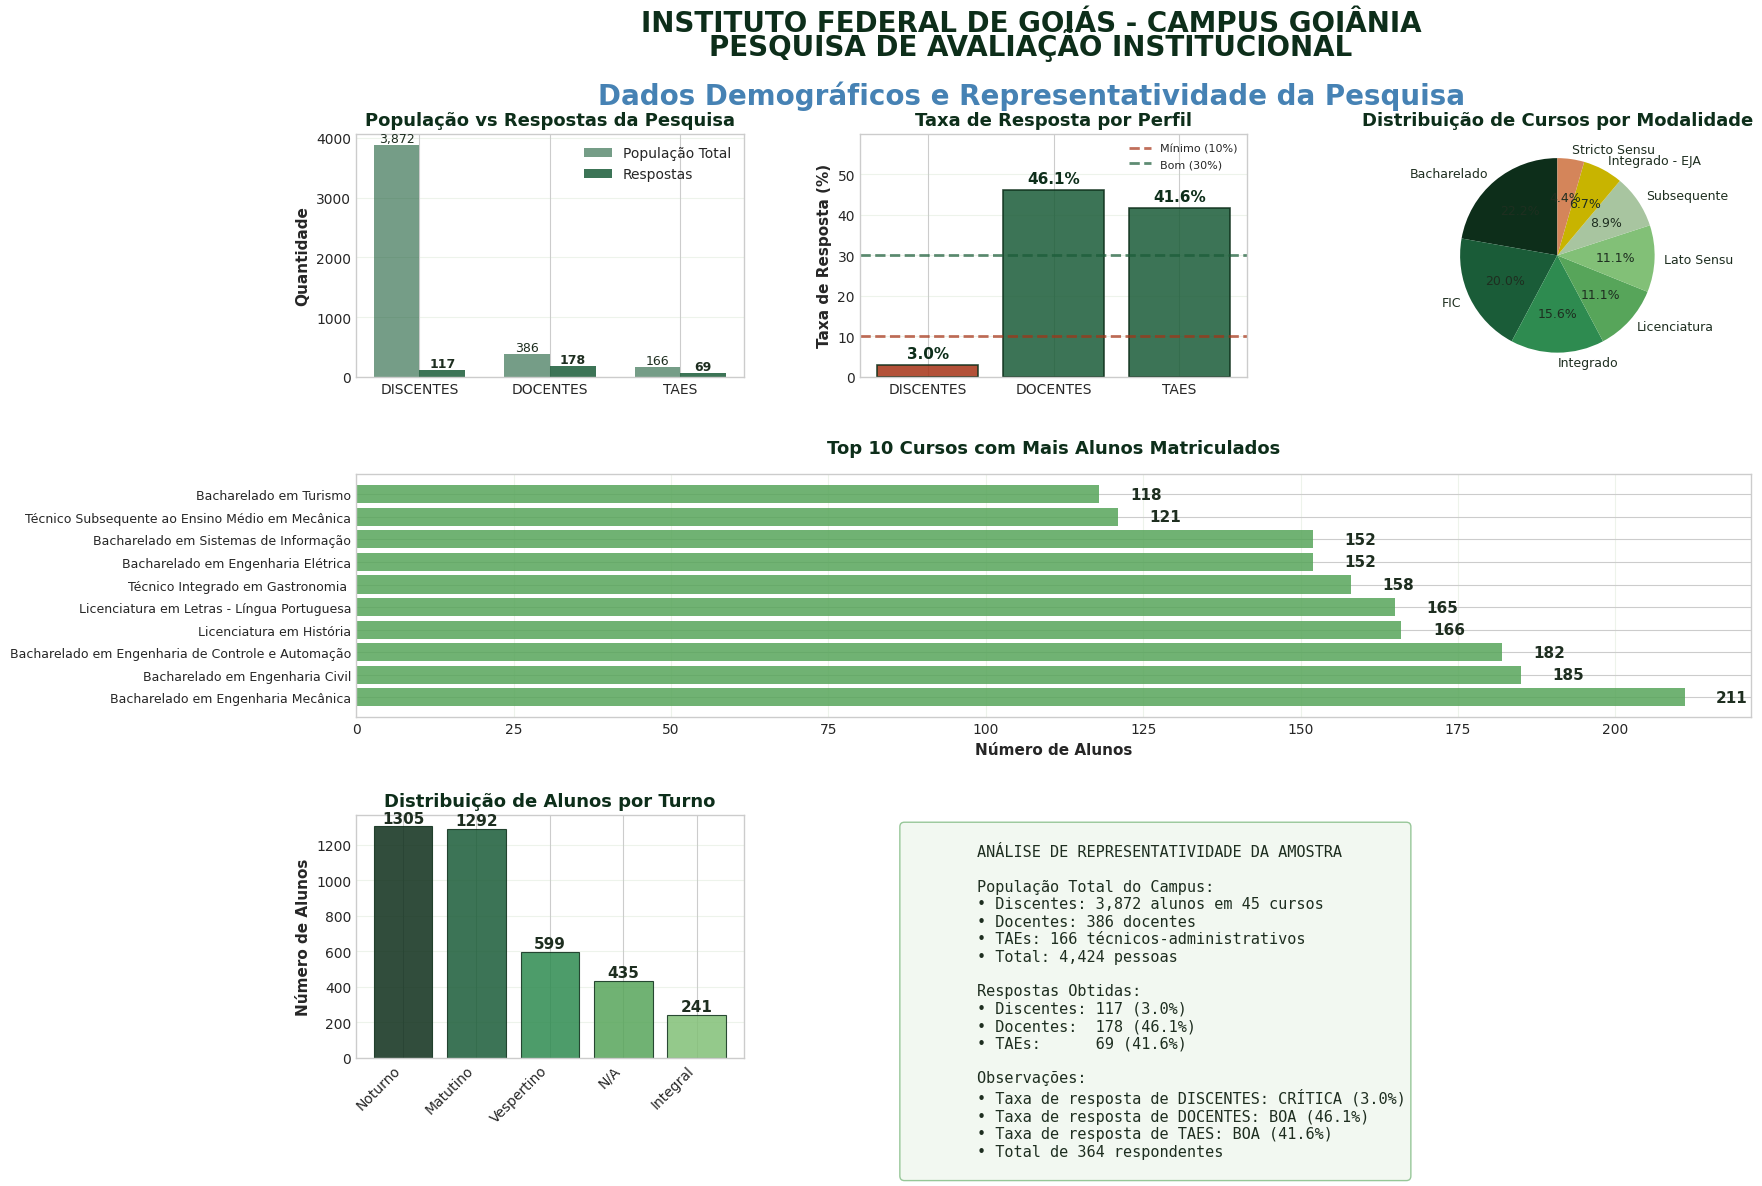

In [18]:
# Criar instância do analisador
analisador = AnalisadorPesquisa(
    ARQUIVO_PESQUISA=arquivo_pesquisa,
    caminho_demografico=arquivo_demografico
)

# Executar análise completa
# Isso irá gerar:
# - analise_demografica.png (se arquivo demográfico fornecido)
# - infografico_executivo.png
# - grafico_Eixo_1_-_Dimensão_8.png
# - grafico_Eixo_2_-_Dimensão_1.png
# - grafico_Eixo_2_-_Dimensão_3.png
# - relatorio_completo.xlsx
# - 3 tabelas CSV

print("\n" + "="*80)
print(" INICIANDO ANÁLISE COMPLETA")
print("="*80)

analisador.executar_analise_completa()

## 6. Visualização dos Dados Carregados

Explore os dados carregados:

In [ ]:
# Resumo geral
print("="*80)
print("RESUMO DOS DADOS CARREGADOS")
print("="*80)

for perfil in ['DISCENTES', 'DOCENTES', 'TAES']:
    df = analisador.dados[perfil]
    print(f"\n{perfil}:")
    print(f"  - Total de respostas: {len(df)}")
    print(f"  - Colunas (questões): {len(df.columns)}")
    print(f"  - Primeiras 3 linhas:")
    display(df.head(3))

## 7. Dados Demográficos (se disponível)

Visualize os dados demográficos e taxas de resposta:

In [ ]:
if analisador.dados_demograficos['total_alunos'] > 0:
    print("="*80)
    print("DADOS DEMOGRÁFICOS")
    print("="*80)
    
    # População
    print(f"\n POPULAÇÃO TOTAL DO CAMPUS:")
    print(f"   - Discentes: {analisador.dados_demograficos['total_alunos']:,} alunos")
    print(f"   - Docentes: {analisador.dados_demograficos['total_docentes']} docentes")
    print(f"   - TAEs: {analisador.dados_demograficos['total_taes']} técnicos")
    total = (analisador.dados_demograficos['total_alunos'] + 
             analisador.dados_demograficos['total_docentes'] + 
             analisador.dados_demograficos['total_taes'])
    print(f"   - TOTAL: {total:,} pessoas")
    
    # Taxas de resposta
    print(f"\n TAXAS DE RESPOSTA:")
    for perfil, dados in analisador.dados_demograficos['taxa_resposta'].items():
        #status = "" if dados['taxa'] >= 30 else "(baixa)" if dados['taxa'] >= 10 else "(insuficiente)
        status=''
        print(f"   {status} {perfil}: {dados['respostas']}/{dados['populacao']} = {dados['taxa']:.1f}%")
    
    # Cursos
    if analisador.dados_demograficos['cursos'] is not None:
        print(f"\n CURSOS:")
        print(f"   - Total de cursos: {len(analisador.dados_demograficos['cursos'])}")
        print(f"\n   Top 5 cursos com mais alunos:")
        top5 = analisador.dados_demograficos['cursos'].nlargest(5, 'Total_Alunos')
        for idx, row in top5.iterrows():
            print(f"      {row['Total_Alunos']:3d} - {row['Curso'][:60]}")
else:
    print("  Dados demográficos não foram carregados")

## 8. Análises das Questões por Perfil

sintetiza os resultados para cada perfil de respondente:

In [ ]:
# # for perfil in ['DISCENTES', 'DOCENTES', 'TAES']:
# #     questoes = [col for iterador, col in enumerate(analisador.dados[perfil].columns) if iterador >= 2]  # Considera apenas colunas a partir da terceira (coluna C)

# #     # Prepara a figura com 2 colunas e N linhas
# #     n_cols = 2
# #     n_rows = math.ceil(len(questoes) / n_cols)
# #     fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
# #     fig.suptitle(f'{perfil}\n', fontsize=14, fontweight='bold')
# #     axes = axes.flatten()  # Array 1D para iterar
    
# #     for i, questao in enumerate(questoes):
# #         ax = axes[i]
        
# #         # Pega a série e calcula os percentuais e as quantidades
# #         serie_respostas = analisador.dados[perfil][questao]
# #         percentuais = analisador.calcular_percentuais(serie_respostas)
# #         totais = analisador.calcular_totais(serie_respostas)

# #         # Ordem da escala ('Ótimo', 'Bom',...) e as cores
# #         escalas = analisador.escalas
# #         valores = [percentuais[esc] for esc in escalas]
# #         cores = [analisador.cores_escala[esc] for esc in escalas]
# #         totais_valores = [totais[esc] for esc in escalas]
# #         bars = ax.bar(escalas, valores, color=cores, alpha=0.85, edgecolor='black')
        
# #         # retira ENTER se existir
# #         titulo_questao = questao.replace('\n', ' ')
# #         titulo_questao = textwrap.fill(titulo_questao, width=85) #quebra o titulo em linhas de no maximo 85 caracteres
# #         ax.set_title(f"{titulo_questao}", fontsize=12)#, fontweight='bold', pad=15)
        
# #         ax.set_ylabel('Percentual (%)', fontweight='bold')
# #         limite_superior = max(valores) * 1.2 if max(valores) > 0 else 100
# #         ax.set_ylim(0, limite_superior)
# #         ax.grid(axis='y', alpha=0.3)
# #         #plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# #         # Adiciona as legendas no topo de cada barra com os valores reais abaixo
# #         for bar, valor, total in zip(bars, valores, totais_valores):
# #             if total > 0:
# #                 ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 1,
# #                         f'{valor:.1f}%\n({total})', ha='center', va='bottom', fontweight='bold')
# #                 #plota os totais dentro da barra respectiva
# #                 ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() - 1,
# #                     f'n={total}', ha='center', va='top', fontweight='bold', fontsize=10, color='white')

# #     # Remove os eixos não usados se houver questões em quantidade ímpar
# #     for j in range(len(questoes), len(axes)):
# #         fig.delaxes(axes[j])
        
# #     plt.tight_layout()
# #     plt.show()



In [ ]:
## 9. Análise Geral das Questões

compara as questões entre os perfis:

In [ ]:
    # # questoes = [col for iterador, col in enumerate(analisador.dados['DOCENTES'].columns) if iterador >= 2]   # Considera apenas colunas a partir da terceira (coluna C)

    # # for questao in questoes:
    # #     fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # #     titulo_questao = questao.replace('\n', ' ')
    # #     titulo_questao = textwrap.fill(titulo_questao, width=95)
    # #     fig.suptitle(f'{titulo_questao}', fontsize=14, fontweight='bold')
        
    # #     for idx, (perfil, ax) in enumerate(zip(['DISCENTES', 'DOCENTES', 'TAES'], axes)):
    # #         df = analisador.dados[perfil]

    # #         # Encontrar coluna\n",
    # #         coluna = None
    # #         col_number = 0
    # #         for col in df.columns:
    # #             col_number =+ 1
    # #             if questao.lower() in col.lower():
    # #                 coluna = col
    # #                 break
            
    # #         if coluna:
    # #             #se for a coluna F e a aba Discentes, desconsidera, pois essa pergunta não foi aplicada as discentes
    # #             if col_number == 6:
    # #                 if perfil == 'DISCENTES':
    # #                     break

    # #             percentuais = analisador.calcular_percentuais(df[coluna])
    # #             cores = [analisador.cores_escala[e] for e in analisador.escalas]
    # #             valores = [percentuais[e] for e in analisador.escalas]
                
    # #             bars = ax.bar(analisador.escalas, valores, color=cores, alpha=0.85, edgecolor='black')
    # #             ax.set_title(perfil, fontweight='bold', fontsize=12)
    # #             ax.set_ylabel('Percentual (%)', fontweight='bold')
    # #             ax.set_ylim(0, max(valores) * 1.2)
    # #             ax.grid(axis='y', alpha=0.3)
    # #             plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
                
    # #             for bar, valor in zip(bars, valores):
    # #                 if valor > 2:
    # #                     ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
    # #                         f'{valor:.1f}%\n({total})', ha='center', va='bottom', fontweight='bold', fontsize=9)
    # #                     #plota os totais dentro da barra respectiva
    # #                     ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() - 1,
    # #                         f'n={total}', ha='center', va='top', fontweight='bold', fontsize=10, color='white')
    
    # #     plt.tight_layout()
    # #     plt.show()

In [ ]:
# # # Exemplo: Análise de distribuição geral por escala

# # print(" DISTRIBUIÇÃO GERAL DE AVALIAÇÕES (todas as questões e perfis)\n")

# # # Consolidar todas as respostas
# # todas_respostas = []
# # for perfil, df in analisador.dados.items():
# #     for col in df.columns[2:]:  # Pular colunas de identificação
# #         respostas = df[col].dropna().tolist()
# #         if any(escala in str(respostas) for escala in analisador.escalas):
# #             todas_respostas.extend(respostas)

# # # Calcular distribuição
# # serie_total = pd.Series(todas_respostas)
# # distribuicao = serie_total.value_counts()

# # # Visualizar
# # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# # # Gráfico de barras
# # cores = [analisador.cores_escala.get(escala, '#95a5a6') for escala in distribuicao.index]
# # bars = ax1.bar(range(len(distribuicao)), distribuicao.values, color=cores, alpha=0.85, edgecolor='black')
# # ax1.set_xticks(range(len(distribuicao)))
# # ax1.set_xticklabels(distribuicao.index, rotation=45, ha='right')
# # ax1.set_ylabel('Quantidade de Respostas', fontweight='bold')
# # ax1.set_title('Distribuição Absoluta', fontweight='bold', fontsize=13)
# # ax1.grid(axis='y', alpha=0.3)

# # for bar, valor in zip(bars, distribuicao.values):
# #     ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
# #             f'{int(valor)}', ha='center', va='bottom', fontweight='bold')

# # # Gráfico de pizza
# # ax2.pie(distribuicao.values, labels=distribuicao.index, autopct='%1.1f%%',
# #        colors=cores, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
# # ax2.set_title('Distribuição Percentual', fontweight='bold', fontsize=13)

# # plt.tight_layout()
# # plt.show()

# # # Tabela resumo
# # print("\nResumo Estatístico:")
# # resumo = pd.DataFrame({
# #     'Escala': distribuicao.index,
# #     'Quantidade': distribuicao.values,
# #     'Percentual': (distribuicao.values / distribuicao.sum() * 100).round(1)
# # })
# # display(resumo)

## 9. Download dos Arquivos Gerados

Faça download de todos os arquivos criados:

In [ ]:
from google.colab import files
import os

# Lista de arquivos gerados
arquivos_gerados = [
    'relatorio_completo.xlsx',
    'infografico_executivo.png',
    'grafico_Eixo_1_-_Dimensão_8.png',
    'grafico_Eixo_2_-_Dimensão_1.png',
    'grafico_Eixo_2_-_Dimensão_3.png',
    'tabela_Eixo_1_-_Dimensão_8.csv',
    'tabela_Eixo_2_-_Dimensão_1.csv',
    'tabela_Eixo_2_-_Dimensão_3.csv'
]

# Adicionar análise demográfica se disponível
if os.path.exists('analise_demografica.png'):
    arquivos_gerados.insert(0, 'analise_demografica.png')

print(" Preparando arquivos para download...\n")

for arquivo in arquivos_gerados:
    if os.path.exists(arquivo):
        print(f"    {arquivo}")
        files.download(arquivo)
    else:
        print(f"     {arquivo} não encontrado")

print("\n Download concluído!")
print("\n DICA: Organize os arquivos em uma pasta para facilitar o acesso")

## 10. Resumo dos Resultados

Visualize um resumo executivo dos principais resultados:

In [ ]:
print("="*80)
print("RESUMO EXECUTIVO DA ANÁLISE")
print("="*80)

# Participação
total_resp = sum([len(df) for df in analisador.dados.values()])
print(f"\n PARTICIPAÇÃO:")
print(f"   - Total de respondentes: {total_resp}")
for perfil, df in analisador.dados.items():
    perc = (len(df) / total_resp) * 100
    print(f"   - {perfil}: {len(df)} ({perc:.1f}%)")

# Taxa de resposta (se disponível)
if analisador.dados_demograficos['total_alunos'] > 0:
    print(f"\n TAXA DE RESPOSTA:")
    for perfil, dados in analisador.dados_demograficos['taxa_resposta'].items():
        status = " EXCELENTE" if dados['taxa'] >= 40 else "✓ BOA" if dados['taxa'] >= 30 else " REGULAR" if dados['taxa'] >= 10 else " BAIXA"
        print(f"   - {perfil}: {dados['taxa']:.1f}% {status}")

# Arquivos gerados
print(f"\n ARQUIVOS GERADOS:")
arquivos = [
    ('analise_demografica.png', 'Análise demográfica'),
    ('infografico_executivo.png', 'Infográfico executivo'),
    ('grafico_Eixo_1_-_Dimensão_8.png', 'Gráfico Eixo 1'),
    ('grafico_Eixo_2_-_Dimensão_1.png', 'Gráfico Eixo 2.1'),
    ('grafico_Eixo_2_-_Dimensão_3.png', 'Gráfico Eixo 2.3'),
    ('relatorio_completo.xlsx', 'Relatório Excel'),
    ('tabela_Eixo_1_-_Dimensão_8.csv', 'Tabela CSV Eixo 1'),
    ('tabela_Eixo_2_-_Dimensão_1.csv', 'Tabela CSV Eixo 2.1'),
    ('tabela_Eixo_2_-_Dimensão_3.csv', 'Tabela CSV Eixo 2.3')
]

for arquivo, descricao in arquivos:
    if os.path.exists(arquivo):
        tamanho = os.path.getsize(arquivo) / 1024
        print(f"    {descricao}: {arquivo} ({tamanho:.1f} KB)")

print(f"\n ANÁLISE COMPLETA FINALIZADA!")
print(f"\n Próximos passos:")
print(f"   1. Baixe todos os arquivos gerados (célula anterior)")
print(f"   2. Compartilhe os resultados com a equipe CPA")
print(f"   3. Planeje ações com base nos insights obtidos")

In [ ]:
 ## 11. Conclusões e Próximos Passos

---

## Conclusão e Recomendações

### Principais Achados
- Revise o infográfico executivo para visão geral
- Analise os gráficos por eixo-dimensão para detalhes
- Verifique as taxas de resposta (se disponível)

### Próximas Ações
1. **Se taxa de discentes baixa**: Ampliar estratégias de divulgação
2. **Análises futuras**: Comparar com anos anteriores
3. **Melhorias**: Desenvolver planos de ação baseados nos 
4. **Desenvolver planos de ação para melhoria contínua
5. **Compartilhar/divulgar resultados com a comunidade institucional

---
